# Risk Analysis of Portfolio

In [1]:
# standard packages
import datetime
import math
import os
from typing import List

# open source packages
import matplotlib.pyplot as plt
import pandas as pd

## Drawdown Functions

In [2]:
from sport.utils import drawdown

## Return Calculation Function

In [3]:
from sport.utils import calc_rtrns_all, calc_port_rtrns

## Drawdown Analysis

In [4]:
data_dir = os.path.join(os.getcwd(), "data", "etf")
output_dir = os.path.join(os.getcwd(), 'output')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
print(data_dir, output_dir)

C:\Users\zypub\PycharmProjects\sport\data\etf C:\Users\zypub\PycharmProjects\sport\output


### Single ticker drawdown

In [5]:
ticker = "SPY"

data = pd.read_csv(os.path.join(data_dir, f"""{ticker}.csv"""))
data['DATE'] = [datetime.datetime.strptime(x, "%Y-%m-%d").date() for x in data['DATE']]

prices = data['CLOSE'].to_list()
print("Prices:", prices[0:3])

rtrns = [math.log(prices[i]) - math.log(prices[i - 1]) for i in range(1, len(prices))] 
print("Log returns:", rtrns[0:2])

dd = drawdown(rtrns=rtrns, type='log')
dd.index = data['DATE']
dd.to_csv(os.path.join(output_dir, f"""{ticker}_dd.csv"""), index=True)
print(dd.head())


Prices: [82.31668090820312, 81.31080627441406, 80.74971771240234]
Log returns: [-0.01229484510229728, -0.006924459950347739]
            cum_rtrn  max_cum_rtrn  drawdown
DATE                                        
2005-01-03  0.000000           0.0  0.000000
2005-01-04 -0.012295           0.0  0.012295
2005-01-05 -0.019219           0.0  0.019219
2005-01-06 -0.014148           0.0  0.014148
2005-01-07 -0.015582           0.0  0.015582


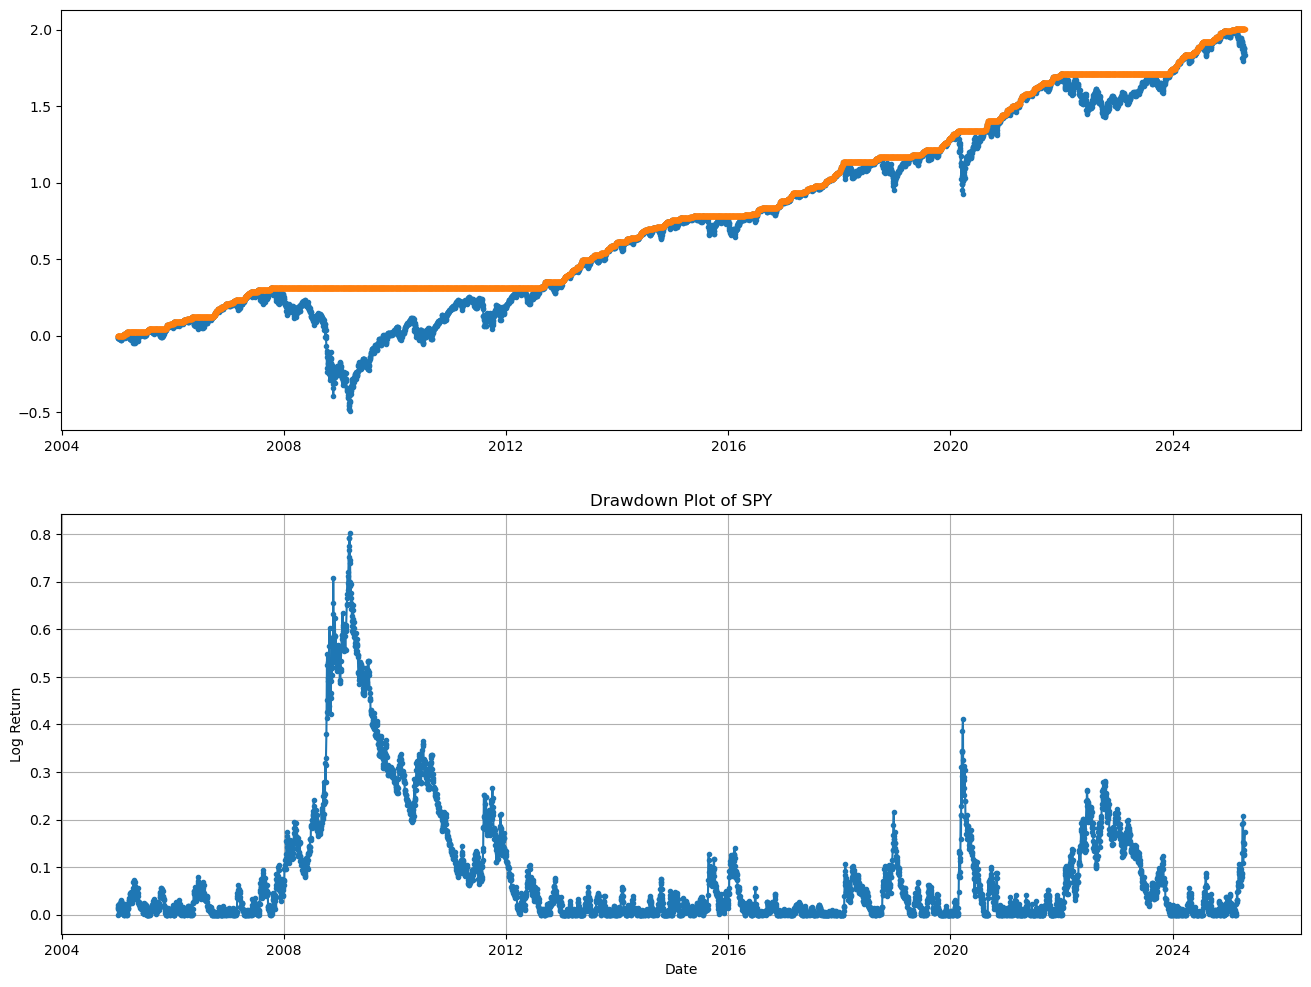

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16,12))

axes[0].plot(dd.index, dd['cum_rtrn'], marker='.', linestyle='-')
axes[0].plot(dd.index, dd['max_cum_rtrn'], marker='.', linestyle='-')

axes[1].plot(dd.index, dd['drawdown'], marker='.', linestyle='-')

plt.title(f"""Drawdown Plot of {ticker}""")
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)

plt.show()

### Portfolio drawdown

In [7]:
tickers = ['AGG', 'BND', 'DBC', 'GSG', 'JNK', 'SPY', 'TIP', 'VBR', 'VNQ', 'VTI', 'VTV', 'VWO']
start_dt = datetime.date(2007, 12, 11)
end_dt = datetime.date(2025, 4, 21)
rtrns_all = calc_rtrns_all(tickers=tickers,
                           data_dir=data_dir,
                           start_dt=start_dt,
                           end_dt=end_dt)
print(rtrns_all.describe())
print(rtrns_all.head(3))
print(rtrns_all.tail(3))

               AGG          BND          DBC          GSG          JNK  \
count  4366.000000  4366.000000  4366.000000  4366.000000  4366.000000   
mean      0.000106     0.000107    -0.000048    -0.000194     0.000180   
std       0.003491     0.003354     0.012263     0.015047     0.007447   
min      -0.070846    -0.055919    -0.082778    -0.128755    -0.156730   
25%      -0.001417    -0.001416    -0.006203    -0.007617    -0.001967   
50%       0.000187     0.000238     0.000624     0.000594     0.000274   
75%       0.001705     0.001753     0.006557     0.007728     0.002547   
max       0.037958     0.041334     0.066484     0.073432     0.106751   

               SPY          TIP          VBR          VNQ          VTI  \
count  4366.000000  4366.000000  4366.000000  4366.000000  4366.000000   
mean      0.000361     0.000118     0.000302     0.000228     0.000357   
std       0.012724     0.004059     0.015473     0.019230     0.012861   
min      -0.115887    -0.029976    -0

                 BND       VTI  Portfolio
DATE                                     
2007-12-12 -0.001953  0.006316   0.004662
2007-12-13 -0.005096  0.000135  -0.000911
2007-12-14 -0.002230 -0.013769  -0.011461
2007-12-17  0.004193 -0.015424  -0.011500
2007-12-18  0.002350  0.007154   0.006193
            cum_rtrn  max_cum_rtrn  drawdown
2007-12-11  0.000000      0.000000  0.000000
2007-12-12  0.004662      0.004662  0.000000
2007-12-13  0.003751      0.004662  0.000911
2007-12-14 -0.007710      0.004662  0.012372
2007-12-17 -0.019210      0.004662  0.023872


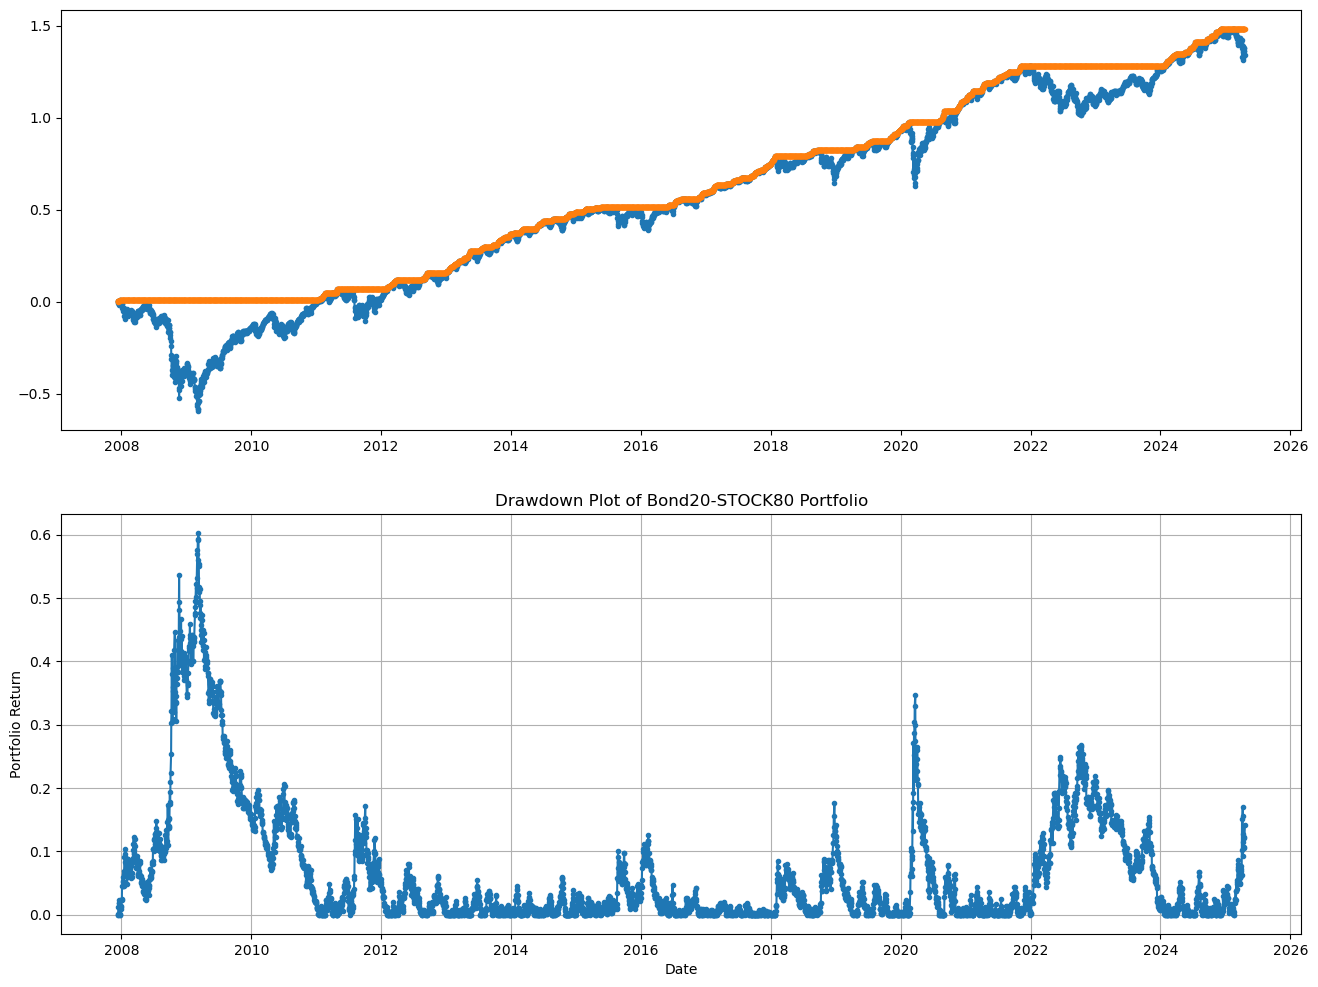

In [8]:
rtrns_2080 = calc_port_rtrns(rtrns_all, {'BND': 0.2, 'VTI': 0.8 })
print(rtrns_2080.head())

dd_2080 = drawdown(rtrns=rtrns_2080['Portfolio'].to_list(), type='log')
dd_2080.index = [start_dt] + list(rtrns_all.index)
print(dd_2080.head())

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16,12))

axes[0].plot(dd_2080.index, dd_2080['cum_rtrn'], marker='.', linestyle='-')
axes[0].plot(dd_2080.index, dd_2080['max_cum_rtrn'], marker='.', linestyle='-')
axes[1].plot(dd_2080.index, dd_2080['drawdown'], marker='.', linestyle='-')

plt.title(f"""Drawdown Plot of Bond20-STOCK80 Portfolio""")
plt.xlabel('Date')
plt.ylabel('Portfolio Return')

plt.grid(True)

plt.show()

In [9]:
# minimal risk portfolio: 50% stock, 30% bond, 20% alternative
label1 = 'MinimalRisk'
weights1 = {'AGG': 0.0655, 'BND': 0.15, 'DBC': 0.15, 'GSG': 0.05, 'SPY': 0.15, 'TIP': 0.0845, 'VTI': 0.1125, 'VTV': 0.15, 'VWO': 0.0875}

label2 = 'Bond50_Stock50'
weights2 = {'BND': 0.5, 'VTI': 0.5 }

label3 = 'Bond20_Stock80'
weights3 = {'BND': 0.2, 'VTI': 0.8 }

label4 = 'Stock100'
weights4 = {'VTI': 1.0}

port_rtrns = pd.DataFrame(index=rtrns_all.index)
port_dd = pd.DataFrame()
port_dd_dict = dict()
for l, w in [(label1, weights1), (label2, weights2), (label3, weights3), (label4, weights4)]:
    rtrns = calc_port_rtrns(rtrns_all, w)
    r = rtrns['Portfolio'].to_list()
    port_rtrns[l] = r
    labelled_dd = drawdown(r, 'log')
    labelled_dd.index = [start_dt] + list(rtrns_all.index)
    port_dd[l] = labelled_dd['drawdown']
    port_dd_dict[l] = labelled_dd

port_dd.index = [start_dt] + list(rtrns_all.index)

print("\n--- portfolio returns\n\n")
print(port_rtrns.head())
print(port_rtrns.tail())
print(port_rtrns.describe())

print("\n--- portfolio drawdowns\n\n")
print(port_dd.head())
print(port_dd.tail())
print(port_dd.describe())


--- portfolio returns


            MinimalRisk  Bond50_Stock50  Bond20_Stock80  Stock100
DATE                                                             
2007-12-12     0.010743        0.002181        0.004662  0.006316
2007-12-13    -0.005140       -0.002480       -0.000911  0.000135
2007-12-14    -0.010014       -0.007999       -0.011461 -0.013769
2007-12-17    -0.010295       -0.005615       -0.011500 -0.015424
2007-12-18     0.005412        0.004752        0.006193  0.007154
            MinimalRisk  Bond50_Stock50  Bond20_Stock80  Stock100
DATE                                                             
2025-04-14     0.006962        0.007421        0.008468  0.009165
2025-04-15    -0.001250        0.000370       -0.000898 -0.001743
2025-04-16    -0.005160       -0.009125       -0.016251 -0.021001
2025-04-17     0.003276       -0.000055        0.001231  0.002089
2025-04-21    -0.012383       -0.014788       -0.020348 -0.024055
       MinimalRisk  Bond50_Stock50  Bond20_Stock80 

<Axes: >

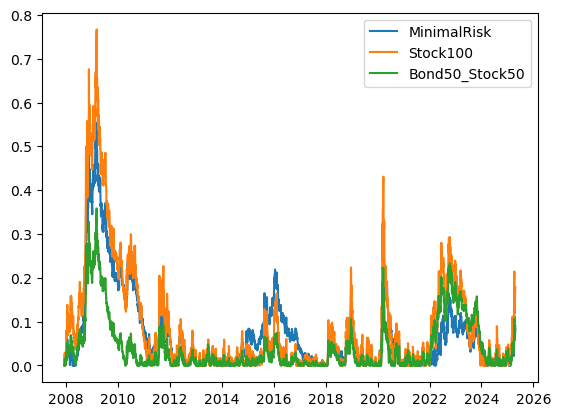

In [10]:
port_dd[['MinimalRisk','Stock100', 'Bond50_Stock50']].plot.line()

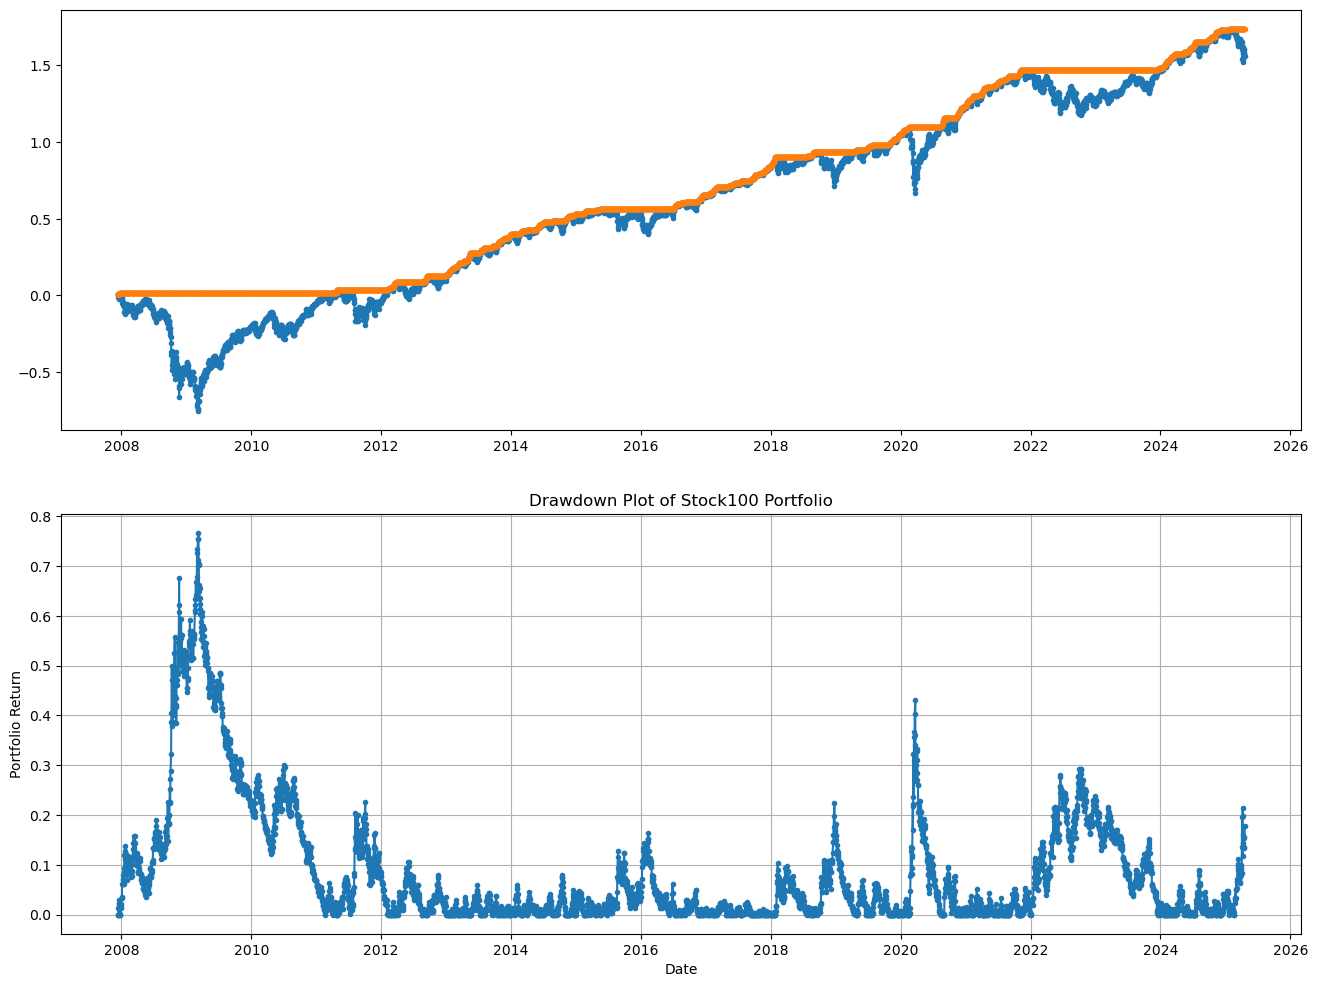

In [11]:
stock100_dr = port_dd_dict['Stock100']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16,12))

axes[0].plot(stock100_dr.index, stock100_dr['cum_rtrn'], marker='.', linestyle='-')
axes[0].plot(stock100_dr.index, stock100_dr['max_cum_rtrn'], marker='.', linestyle='-')
axes[1].plot(stock100_dr.index, stock100_dr['drawdown'], marker='.', linestyle='-')

plt.title(f"""Drawdown Plot of Stock100 Portfolio""")
plt.xlabel('Date')
plt.ylabel('Portfolio Return')

plt.grid(True)

plt.show()

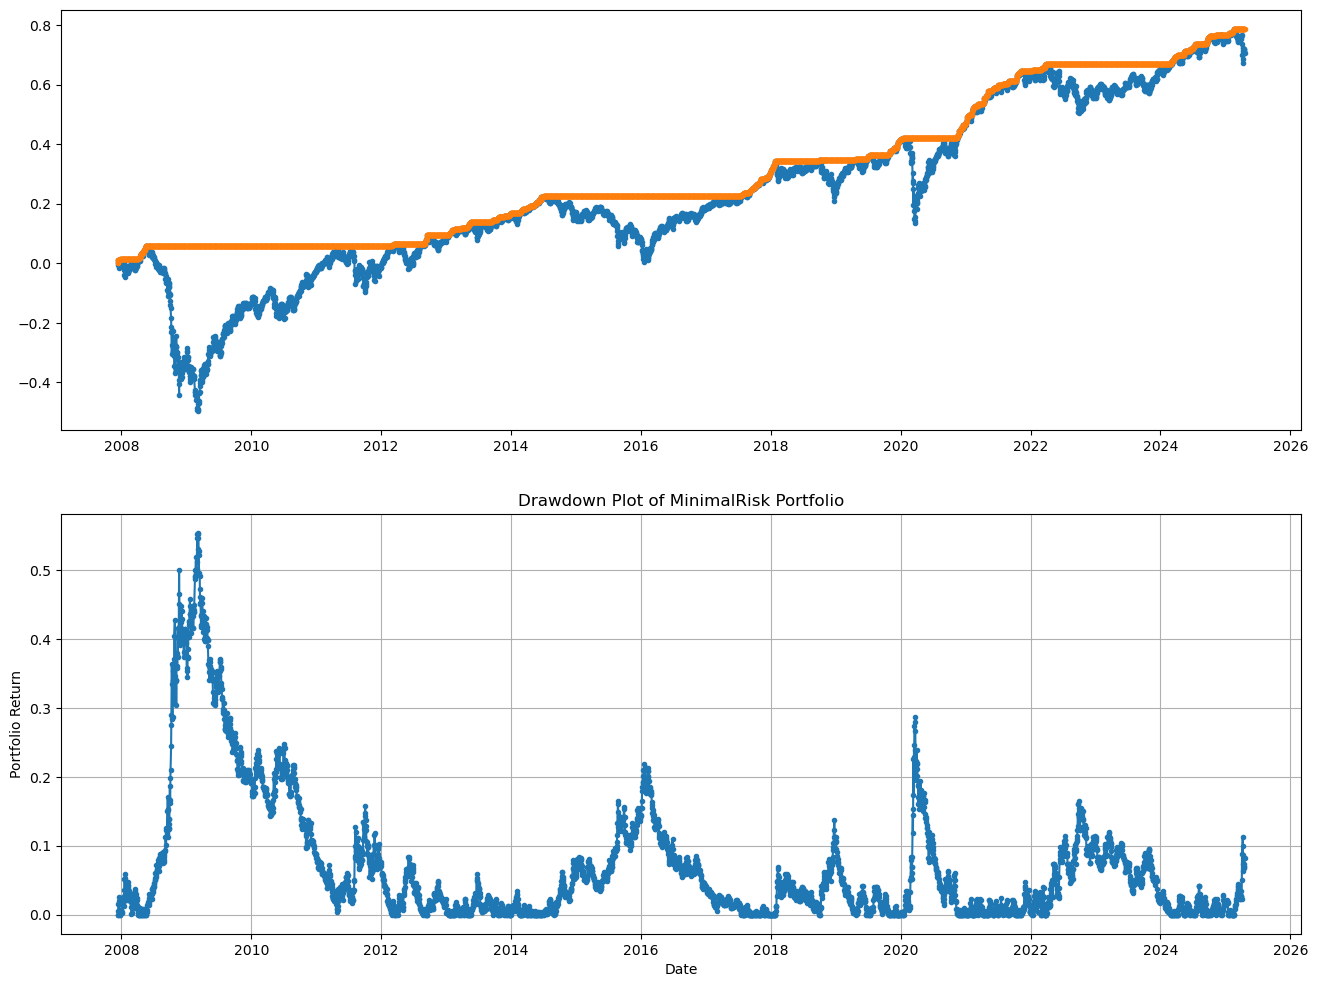

In [12]:
mr_dr = port_dd_dict['MinimalRisk']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16,12))

axes[0].plot(mr_dr.index, mr_dr['cum_rtrn'], marker='.', linestyle='-')
axes[0].plot(mr_dr.index, mr_dr['max_cum_rtrn'], marker='.', linestyle='-')
axes[1].plot(mr_dr.index, mr_dr['drawdown'], marker='.', linestyle='-')

plt.title(f"""Drawdown Plot of MinimalRisk Portfolio""")
plt.xlabel('Date')
plt.ylabel('Portfolio Return')

plt.grid(True)

plt.show()


In [13]:
mr_dr_zero = mr_dr[mr_dr['drawdown']==0]
print(mr_dr_zero.head())

mr_dr_dur = [mr_dr_zero.index[0]-mr_dr_zero.index[0]]
for i in range(1, len(mr_dr_zero.index)):
    mr_dr_dur.append(mr_dr_zero.index[i]-mr_dr_zero.index[i-1])

mr_dr_dur = pd.DataFrame({'mr_dr_dur': mr_dr_dur})
mr_dr_dur.index = mr_dr_zero.index
print(mr_dr_dur)
print(mr_dr_dur['mr_dr_dur'].max())

            cum_rtrn  max_cum_rtrn  drawdown
2007-12-11  0.000000      0.000000       0.0
2007-12-12  0.010743      0.010743       0.0
2007-12-24  0.010798      0.010798       0.0
2007-12-26  0.013232      0.013232       0.0
2008-04-04  0.015008      0.015008       0.0
           mr_dr_dur
2007-12-11    0 days
2007-12-12    1 days
2007-12-24   12 days
2007-12-26    2 days
2008-04-04  100 days
...              ...
2025-02-11    1 days
2025-02-13    2 days
2025-02-14    1 days
2025-02-18    4 days
2025-02-19    1 days

[336 rows x 1 columns]
1382 days 00:00:00
